In [1]:
import itertools
import matplotlib.pyplot as plt
import pandas as pd
import re
import subprocess

import common

In [2]:
START = 'TACTATTAAAGAG'
ORIGINAL_MIDDLE_SEQ = 'GAGAAA'
SPACER_START_AND_CDS = 'TACTAGAATGCGTAAAGGAGAAGAACTTTTCACTGGAGTTGT'

### Load the cloud dataset and transform it so we have core sequence and associated cloud with mean ETR

In [3]:
# Clouds
clouds = pd.read_csv('data/processed/clusters_with_stats.csv')
clouds.head()

,CLUSTER_,CORE REL EXPR_mean,CORE REL EXPR_std,SEQ_unique
0,0,0.129612,0.017409,"AATTTA,AATTCT,AATTCA,AACTTA,AAATCC,AATATG,AATA..."
1,1,0.229000,NaN,ATCCGC
2,2,0.123416,0.014622,"ACCTAC,ACCTCC,ACATCC,ACATCA,ACATAC,AAATCA,ATAT..."
3,3,0.052767,0.008386,"CGTTCC,CGTCCC,CGTCAC"
4,4,0.104843,0.013261,"CCGAAA,CCGAAT,CCGTGA,CTGCCT,CCGGAC,CAAGTC,CCGG..."


In [4]:
# Create new dataframe, when one column is the core sequence (splitted SEQ_unique) and the others are the cluster and mean expression
clouds_core = (
    clouds
    .assign(SEQ_unique=clouds['SEQ_unique'].str.split(','))
    .explode('SEQ_unique')
    .reset_index(drop=True)
)

clouds_core

,CLUSTER_,CORE REL EXPR_mean,CORE REL EXPR_std,SEQ_unique
0,0,0.129612,0.017409,AATTTA
1,0,0.129612,0.017409,AATTCT
2,0,0.129612,0.017409,AATTCA
3,0,0.129612,0.017409,AACTTA
4,0,0.129612,0.017409,AAATCC
...,...,...,...,...
4091,380,0.090636,0.017817,CCAGTT
4092,380,0.090636,0.017817,GCCATT
4093,380,0.090636,0.017817,GTCTTT
4094,380,0.090636,0.017817,CCCATT


### Create all possible combinations of SD cores

In [5]:
# Generate all possible combinations of A, C, G, T characters in the length of 6
# and store them in the list
all_combinations = [''.join(p) for p in itertools.product('ACGT', repeat=6)]

# Prepare a dataframe to store the results
df_all_combinations = pd.DataFrame(columns=['MIDDLE_SEQ', 'SD_CORE', 'CLOUD', 'CLOUD MEAN ETR', 'GIBBS_MRNA'])

# Insert the combinations to the dataframe
df_all_combinations['MIDDLE_SEQ'] = all_combinations

df_all_combinations

,MIDDLE_SEQ,SD_CORE,CLOUD,CLOUD MEAN ETR,GIBBS_MRNA
0,AAAAAA,NaN,NaN,NaN,NaN
1,AAAAAC,NaN,NaN,NaN,NaN
2,AAAAAG,NaN,NaN,NaN,NaN
3,AAAAAT,NaN,NaN,NaN,NaN
4,AAAACA,NaN,NaN,NaN,NaN
...,...,...,...,...,...
4091,TTTTGT,NaN,NaN,NaN,NaN
4092,TTTTTA,NaN,NaN,NaN,NaN
4093,TTTTTC,NaN,NaN,NaN,NaN
4094,TTTTTG,NaN,NaN,NaN,NaN


In [6]:
# For each row, find the best SD sequence based on Gibbs free energy
df_all_combinations['SD_CORE'] = df_all_combinations['MIDDLE_SEQ'].apply(lambda x: common.find_best_SD(START + x + SPACER_START_AND_CDS)[0])

In [7]:
df_all_combinations

,MIDDLE_SEQ,SD_CORE,CLOUD,CLOUD MEAN ETR,GIBBS_MRNA
0,AAAAAA,AAAATA,NaN,NaN,NaN
1,AAAAAC,AAACTA,NaN,NaN,NaN
2,AAAAAG,AAAGTA,NaN,NaN,NaN
3,AAAAAT,AAATTA,NaN,NaN,NaN
4,AAAACA,AACATA,NaN,NaN,NaN
...,...,...,...,...,...
4091,TTTTGT,TTGTTA,NaN,NaN,NaN
4092,TTTTTA,TTTATA,NaN,NaN,NaN
4093,TTTTTC,TTTCTA,NaN,NaN,NaN
4094,TTTTTG,TTTGTA,NaN,NaN,NaN


In [8]:
# For each row, find the structure and Gibbs free energy of the single mRNA
df_all_combinations['GIBBS_MRNA'] = df_all_combinations['MIDDLE_SEQ'].apply(lambda x: common.run_RNAfold(START + x + SPACER_START_AND_CDS)[1])

In [9]:
# Based on the SD_Core, get the cloud ID and its mean ETR from the clouds dataframe
df_all_combinations["CLOUD"] = df_all_combinations["SD_CORE"].apply(lambda x: clouds_core.loc[clouds_core["SEQ_unique"] == x, "CLUSTER_"].iloc[0])

In [10]:
df_all_combinations["CLOUD MEAN ETR"] = df_all_combinations["CLOUD"].apply(lambda x: clouds_core.loc[clouds_core["CLUSTER_"] == x]["CORE REL EXPR_mean"].iloc[0])

In [11]:
df_all_combinations

,MIDDLE_SEQ,SD_CORE,CLOUD,CLOUD MEAN ETR,GIBBS_MRNA
0,AAAAAA,AAAATA,2,0.123416,-3.2
1,AAAAAC,AAACTA,351,0.098816,-6.3
2,AAAAAG,AAAGTA,246,0.227413,-4.0
3,AAAAAT,AAATTA,2,0.123416,-4.0
4,AAAACA,AACATA,0,0.129612,-3.3
...,...,...,...,...,...
4091,TTTTGT,TTGTTA,212,0.179212,-5.7
4092,TTTTTA,TTTATA,44,0.081985,-6.7
4093,TTTTTC,TTTCTA,234,0.077473,-10.9
4094,TTTTTG,TTTGTA,44,0.081985,-7.1


### Get the sequences with the best and worst Gibbs free energy

In [12]:
# Get all the cores with the highest GIBBS_MRNA value
min_structure = df_all_combinations[df_all_combinations['GIBBS_MRNA'] == df_all_combinations['GIBBS_MRNA'].max()]
# Sort it by cloud mean ETR
min_structure = min_structure.sort_values(by='CLOUD MEAN ETR', ascending=False)

In [13]:
min_structure

,MIDDLE_SEQ,SD_CORE,CLOUD,CLOUD MEAN ETR,GIBBS_MRNA
564,AGATCA,GAGATC,146,0.895100,-3.0
572,AGATTA,GAGATT,144,0.802359,-3.0
904,ATGAGA,GAGATA,144,0.802359,-3.0
1928,CTGAGA,GAGATA,144,0.802359,-3.0
574,AGATTG,GAGATT,144,0.802359,-3.0
524,AGAATA,GAGAAT,152,0.659650,-3.0
652,AGGATA,GAGGAT,152,0.659650,-3.0
708,AGTACA,GAGTAC,149,0.513248,-3.0
776,ATAAGA,ATAAGA,333,0.267907,-3.0
968,ATTAGA,TAGATA,210,0.266811,-3.0


In [14]:
# Get 5 cores with the lowest GIBBS_MRNA value
max_structure = df_all_combinations.sort_values(by='GIBBS_MRNA', ascending=True).head(30)
# Sort it by cloud mean ETR
max_structure = max_structure.sort_values(by='CLOUD MEAN ETR', ascending=False)

In [15]:
max_structure

,MIDDLE_SEQ,SD_CORE,CLOUD,CLOUD MEAN ETR,GIBBS_MRNA
1882,CTCCGG,CCGGTA,194,0.393050,-11.6
2911,GTCCTT,GGTCCT,15,0.392140,-12.2
2399,GCCCTT,GGCCCT,72,0.332367,-11.0
1951,CTGCTT,GCTTTA,28,0.173328,-11.0
2365,GCATTC,GGCATT,37,0.162337,-11.0
1270,CATTCG,TTCGTA,269,0.137965,-11.1
1879,CTCCCT,CCCTTA,53,0.137389,-11.1
1885,CTCCTC,CCTCTA,53,0.137389,-11.6
1886,CTCCTG,CCTGTA,356,0.129921,-11.6
1875,CTCCAT,CCATTA,356,0.129921,-11.1


### Pick 5 representative of sequences with weak secondary structure, based on the quantiles of cloud mean ETR

In [16]:
def pick_by_quantiles(df, col="CLOUD MEAN ETR"):
    qs = [0.0, 0.25, 0.5, 0.75, 1.0]
    targets = df[col].quantile(qs)
    # Pick the row closest to each target value (ties go to the first)
    chosen_idx = []
    for val in targets:
        i = (df[col] - val).abs().idxmin()
        chosen_idx.append(i)
    reps = df.loc[pd.unique(chosen_idx)].sort_values(col)
    # Order by CLOUD MEAN ETR
    reps = reps.sort_values(by='CLOUD MEAN ETR', ascending=False)
    return reps

In [17]:
min_structure_reps = pick_by_quantiles(min_structure, "CLOUD MEAN ETR")
min_structure_reps

C:\Users\Pavel\AppData\Local\Temp\ipykernel_23200\1705103977.py:9: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  reps = df.loc[pd.unique(chosen_idx)].sort_values(col)


,MIDDLE_SEQ,SD_CORE,CLOUD,CLOUD MEAN ETR,GIBBS_MRNA
564,AGATCA,GAGATC,146,0.895100,-3.0
708,AGTACA,GAGTAC,149,0.513248,-3.0
308,ACATCA,ATCATA,355,0.217700,-3.0
60,AAATTA,ATTATA,351,0.098816,-3.0
204,AATATA,TATATA,225,0.074240,-3.0


In [18]:
# Values from the RBS calculator
min_rbs_calc = [750, 361, 152, 152, 526]

### Pick 5 representative of sequences with strong secondary structure, based on the quantiles of cloud mean ETR

In [19]:
max_structure_reps = pick_by_quantiles(max_structure, "CLOUD MEAN ETR")
max_structure_reps

C:\Users\Pavel\AppData\Local\Temp\ipykernel_23200\1705103977.py:9: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  reps = df.loc[pd.unique(chosen_idx)].sort_values(col)


,MIDDLE_SEQ,SD_CORE,CLOUD,CLOUD MEAN ETR,GIBBS_MRNA
1882,CTCCGG,CCGGTA,194,0.393050,-11.6
1879,CTCCCT,CCCTTA,53,0.137389,-11.1
1887,CTCCTT,CCTTTA,224,0.100106,-15.3
3543,TCTCCT,TCCTTA,351,0.098816,-12.0
3542,TCTCCG,TCCGTA,349,0.069152,-10.9


In [20]:
# Values from the RBS Calculator
max_rbs_calc = [113, 19, 4, 9, 34]

### Pick 5 random sequences

In [21]:
RND1 = 'TACTATTAAAGAAAAAATATACTAGAATGCGTAAAGGAGAAGAACTTTTCACTGGAGTTGT' # 694
RND2 = 'TACTATTAAAGAAGGAGTGTACTAGAATGCGTAAAGGAGAAGAACTTTTCACTGGAGTTGT' # 22168
RND3 = 'TACTATTAAAGAAAAAAGATACTAGAATGCGTAAAGGAGAAGAACTTTTCACTGGAGTTGT' # 1181
RND4 = 'TACTATTAAAGAGAGGATATACTAGAATGCGTAAAGGAGAAGAACTTTTCACTGGAGTTGT' # 6247
RND5 = 'TACTATTAAAGGGGGGGCTTACTAGAATGCGTAAAGGAGAAGAACTTTTCACTGGAGTTGT' # 2995

etrs = []

# For each of the exp sequence, get the core and then cloud id and its mean ETR
for exp in [RND1, RND2, RND3, RND4, RND5]:
    core = common.find_best_SD(exp)[0]
    gibbs = common.run_RNAfold(exp)[1]
    cloud_id = clouds_core.loc[clouds_core['SEQ_unique'] == core]['CLUSTER_'].iloc[0]
    mean_etr = clouds_core.loc[clouds_core['CLUSTER_'] == cloud_id]['CORE REL EXPR_mean'].iloc[0]
    etrs.append(mean_etr)
    print(f"Core: {core}, Gibbs: {gibbs}, Cloud ID: {cloud_id}, Mean ETR: {round(mean_etr, 3)}")

exp_for_plots = dict(zip(etrs, [694, 22168, 1181, 6247, 2995]))
# Sort by keys
exp_for_plots = {k: v for k, v in sorted(exp_for_plots.items(), key=lambda item: item[0])}

Core: AATATA, Gibbs: -3.0, Cloud ID: 356, Mean ETR: 0.13
Core: AGGAGT, Gibbs: -3.0, Cloud ID: 100, Mean ETR: 0.784
Core: AAAGAT, Gibbs: -3.0, Cloud ID: 238, Mean ETR: 0.223
Core: GAGGAT, Gibbs: -3.0, Cloud ID: 152, Mean ETR: 0.66
Core: GGGGGC, Gibbs: -4.3, Cloud ID: 267, Mean ETR: 0.257


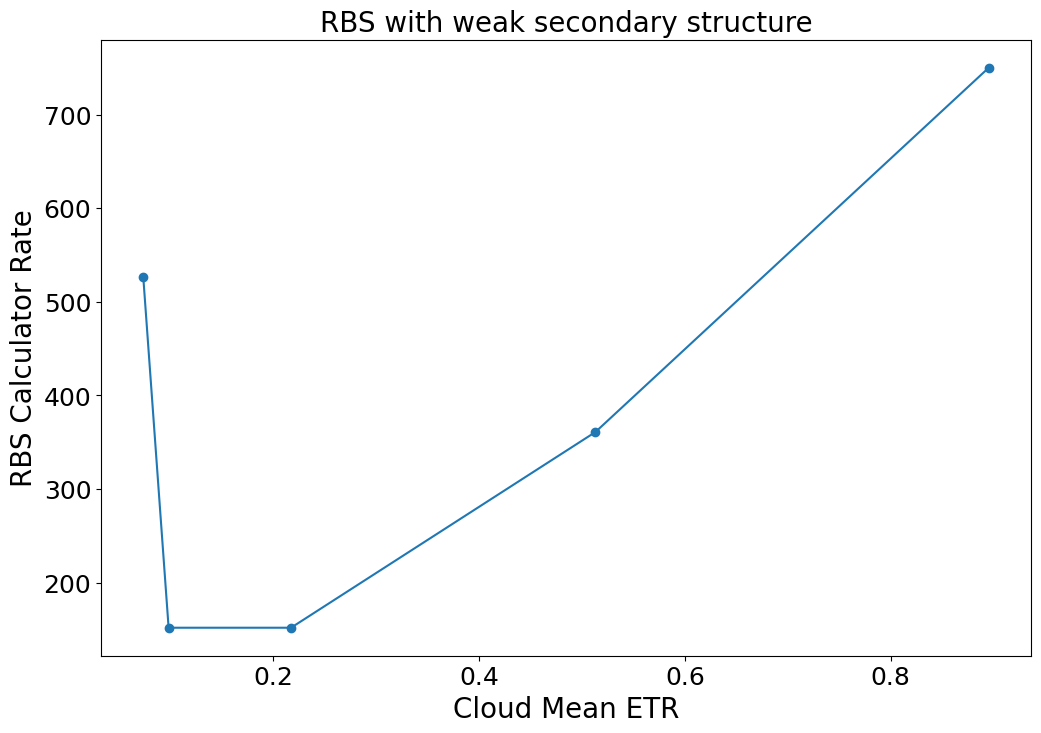

In [28]:
# Plot CLOUD MEAN ETR from min_structure_reps vs min_rbs_calc
plt.figure(figsize=(12, 8))
# Connect the dots with line
plt.plot(min_structure_reps['CLOUD MEAN ETR'], min_rbs_calc, 'o-')
plt.xlabel('Cloud Mean ETR', fontsize=20)
plt.ylabel('RBS Calculator Rate', fontsize=20)
plt.title('RBS with weak secondary structure', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.savefig('rbs_calc_validation_min.eps', format='eps', dpi=200)
plt.show()

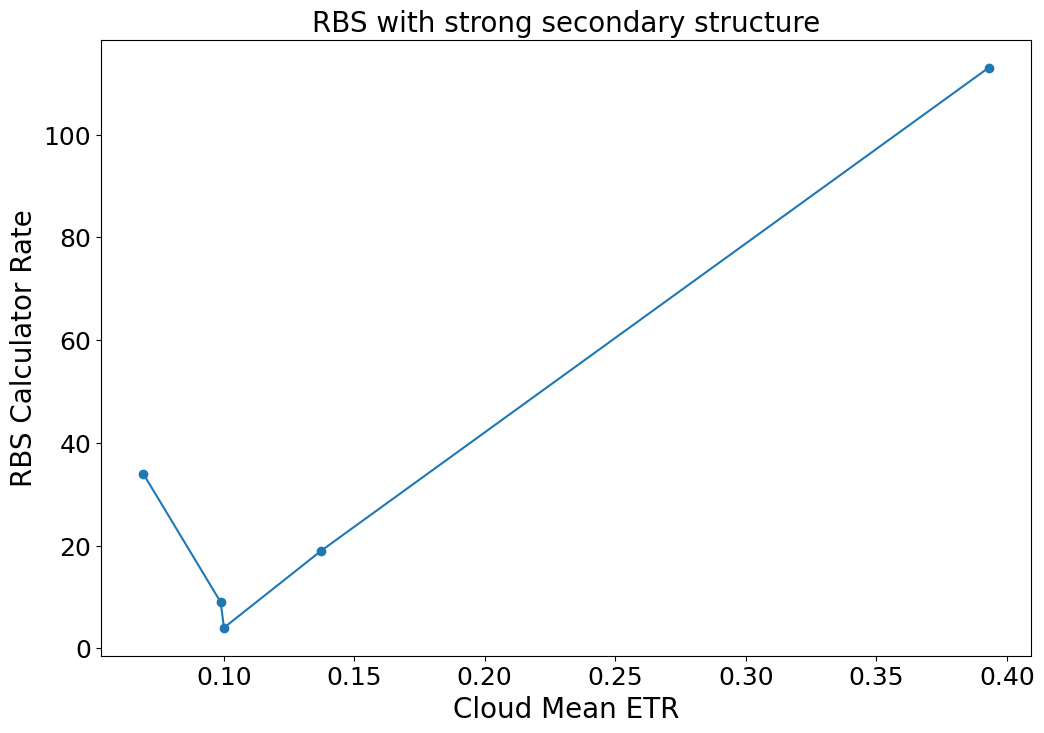

In [27]:
# Plot CLOUD MEAN ETR from max_structure_reps vs max_rbs_calc
plt.figure(figsize=(12, 8))
# Connect the dots with line
plt.plot(max_structure_reps['CLOUD MEAN ETR'], max_rbs_calc, 'o-')
plt.xlabel('Cloud Mean ETR', fontsize=20)
plt.ylabel('RBS Calculator Rate', fontsize=20)
plt.title('RBS with strong secondary structure', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.savefig('rbs_calc_validation_max.eps', format='eps', dpi=200)
plt.show()

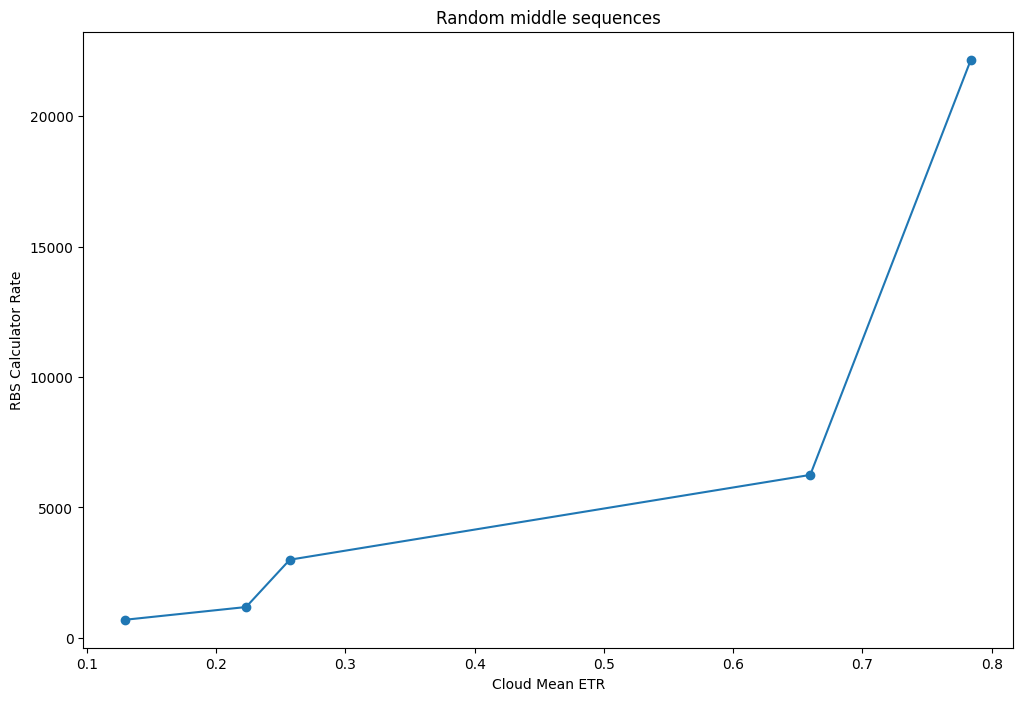

In [24]:
# Plot random data - for experiments
plt.figure(figsize=(12, 8))
plt.plot(exp_for_plots.keys(), exp_for_plots.values(), 'o-')
plt.xlabel('Cloud Mean ETR')
plt.ylabel('RBS Calculator Rate')
plt.title('Random middle sequences')
plt.show()
